In [5]:
import torch
import torchvision
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple mps 😃")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else: 
    device = torch.device("cpu")
    print("Using slow cpu😔")

print(f"Current device: {device}")


Using Apple mps 😃
Current device: mps


In [7]:
#Define transforms
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])
print("transforms setup")

transforms setup


In [13]:
#Load the dataset

celebA = datasets.CelebA(
    root="/Users/talosmann/Projects/schoolwrk",
    split="train",
    target_type="attr",
    transform=transform,
    download=False
)
print("Dataset loaded")

Dataset loaded


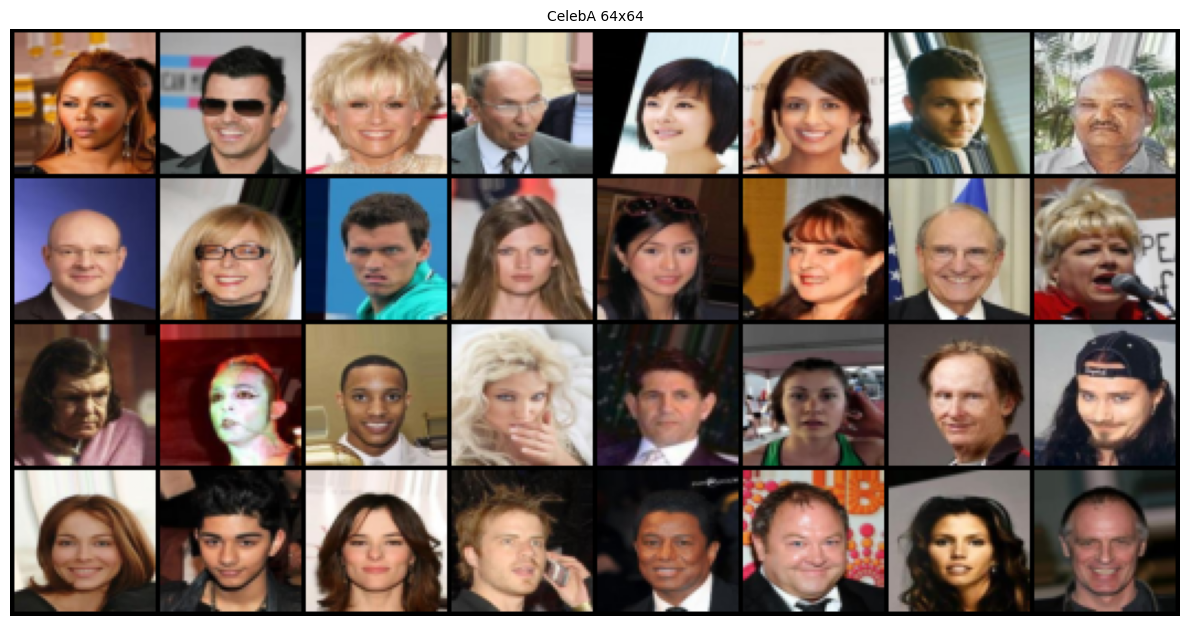


Sample Batch shape:torch.Size([32, 3, 64, 64])
Training Samples:130216
Validation Samples:32554
Training batches:4070


In [22]:
#80/20 training split
full_size = len(celebA)
train_size = int(0.8*full_size)
val_size = full_size - train_size

train_dataset, val_dataset = random_split(
    celebA,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)
#dataloaders potimized for mac

batch_size = 32
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size = batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

#Batch visualization
def visualize_celebA_batch(loader, title="CelebA 64x64"):
    images, _=next(iter(loader))
    images = images.cpu() #mps can't plot directly
    grid = torchvision.utils.make_grid(images, nrow=8, padding=2)
    grid.np = grid.permute(1, 2, 0).numpy()

    plt.figure(figsize=(12, 10))
    plt.imshow(grid.np)
    plt.axis("off")
    plt.title(title, fontsize=10)
    plt.tight_layout()
    plt.show()

visualize_celebA_batch(train_loader)

#Verify dataset and batch details
sample_batch, _=next(iter(train_loader))
print(f"\nSample Batch shape:{sample_batch.shape}")
print(f"Training Samples:{len(train_dataset)}")
print(f"Validation Samples:{len(val_dataset)}")
print(f"Training batches:{len(train_loader)}")